# **EXP A - 01: ConstLW offline**

## **0. Setup**

In [184]:
# Load packages
using Revise
using NeuralLongwave

In [185]:
# Define experiments and general settings
EXP = "exp_A"
SER = "01_CLW_offline"

# Define units
BASELINES = ["b_OBLW", "b_ZeroLW"]
UNITS = ["offline_$(of)" for of in ("direct", "linear", "planck")];

In [186]:
# Load all weather and climate rollouts and timings
w = collect_rollouts(EXP, SER, [BASELINES..., UNITS...]; leg = :weather)
c = collect_rollouts(EXP, SER, [UNITS...]; leg = :climate)
t = load_timings(EXP, SER);

In [187]:
# Test reference
test_reference(w.b_OBLW)

┌ Info: Reference reproduced exactly for every probe and trajectory.
└ @ NeuralLongwave C:\Code\NeuralLongwave.jl\src\evaluation\rollout_weather.jl:86


Row,probe,max_error,n_exact,n_traj,failed_trajs
,Symbol,Float64,Int64,Int64,Array…
1,T,0.0,52,52,Int64[]
2,olw,0.0,52,52,Int64[]
3,slwd,0.0,52,52,Int64[]


In [188]:
# Define all looks
looks = (;
    b_OBLW          = (; label = "OBLW",        color = :black, marker = :star5),
    b_ZeroLW        = (; label = "ZeroLW",      color = :magenta,  marker = :rect),
    clim_noise      = (; label = "OBLW pert.",  color = :black),
    offline_direct  = (; label = "Direct",      color = JL_BLUE),
    offline_linear  = (; label = "Linear",      color = JL_GREEN),
    offline_planck  = (; label = "Planck",      color = JL_RED),
);

## **1. Training**

In [189]:
# Collect training runs
runs = collect_runs(EXP, SER, UNITS);

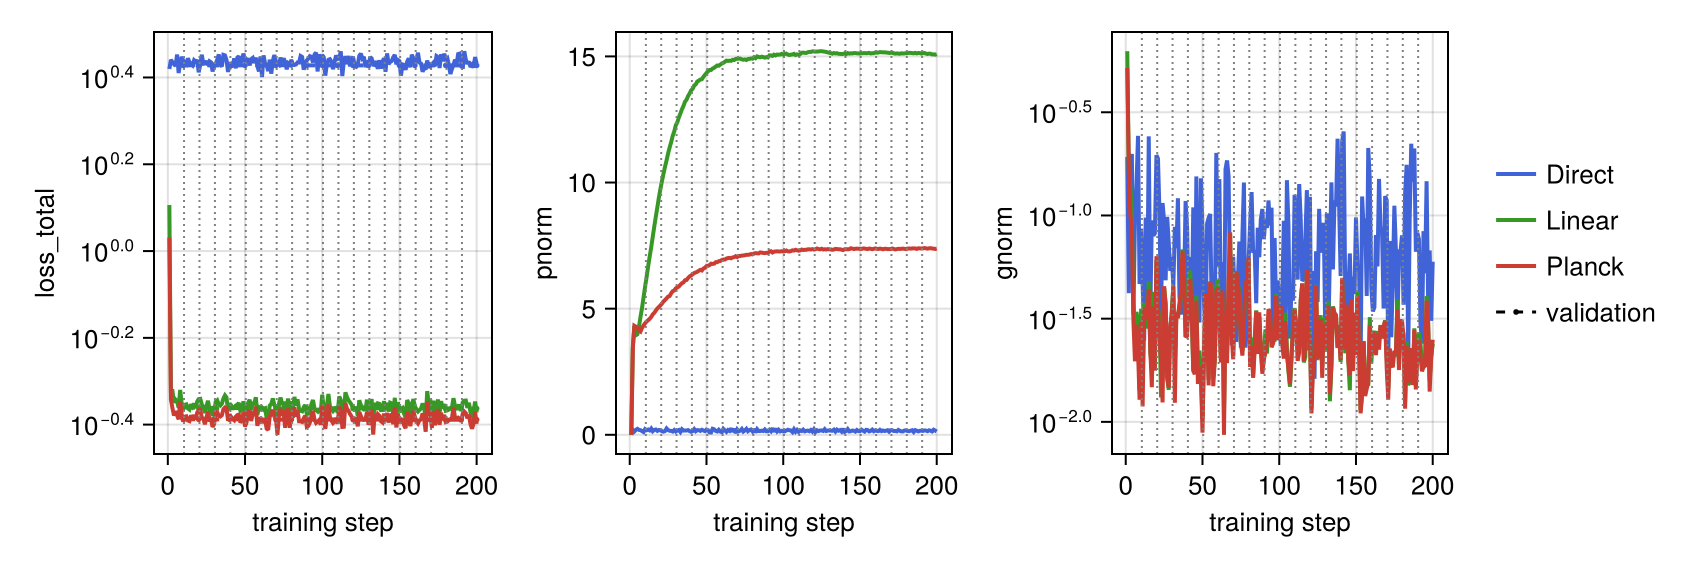

In [190]:
# Plot default plots
plot_training(runs; looks, n_block = 1)

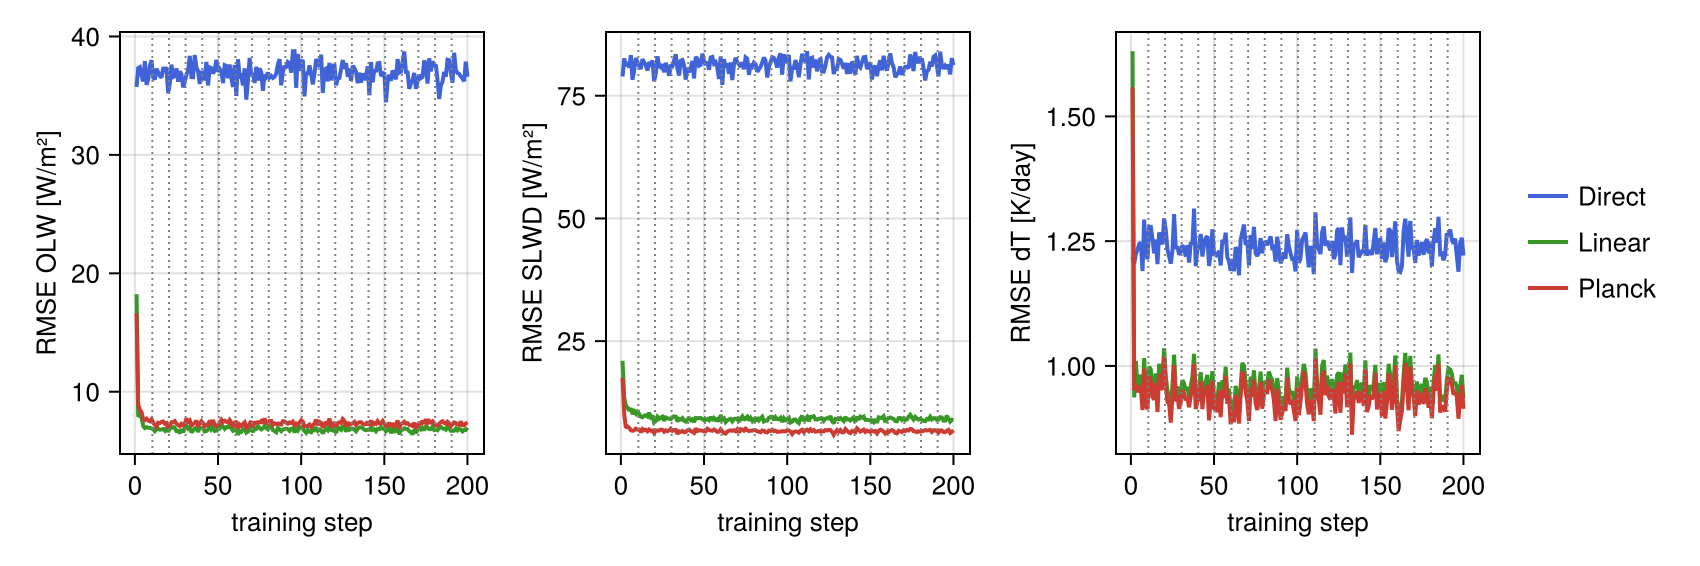

In [191]:
# Plot true variable RMSE
plot_rmse(runs; looks)

## **2. Weather Cost Plane**

In [192]:
# Create tables
wt = weather_table(w)
tt = timing_table(t);

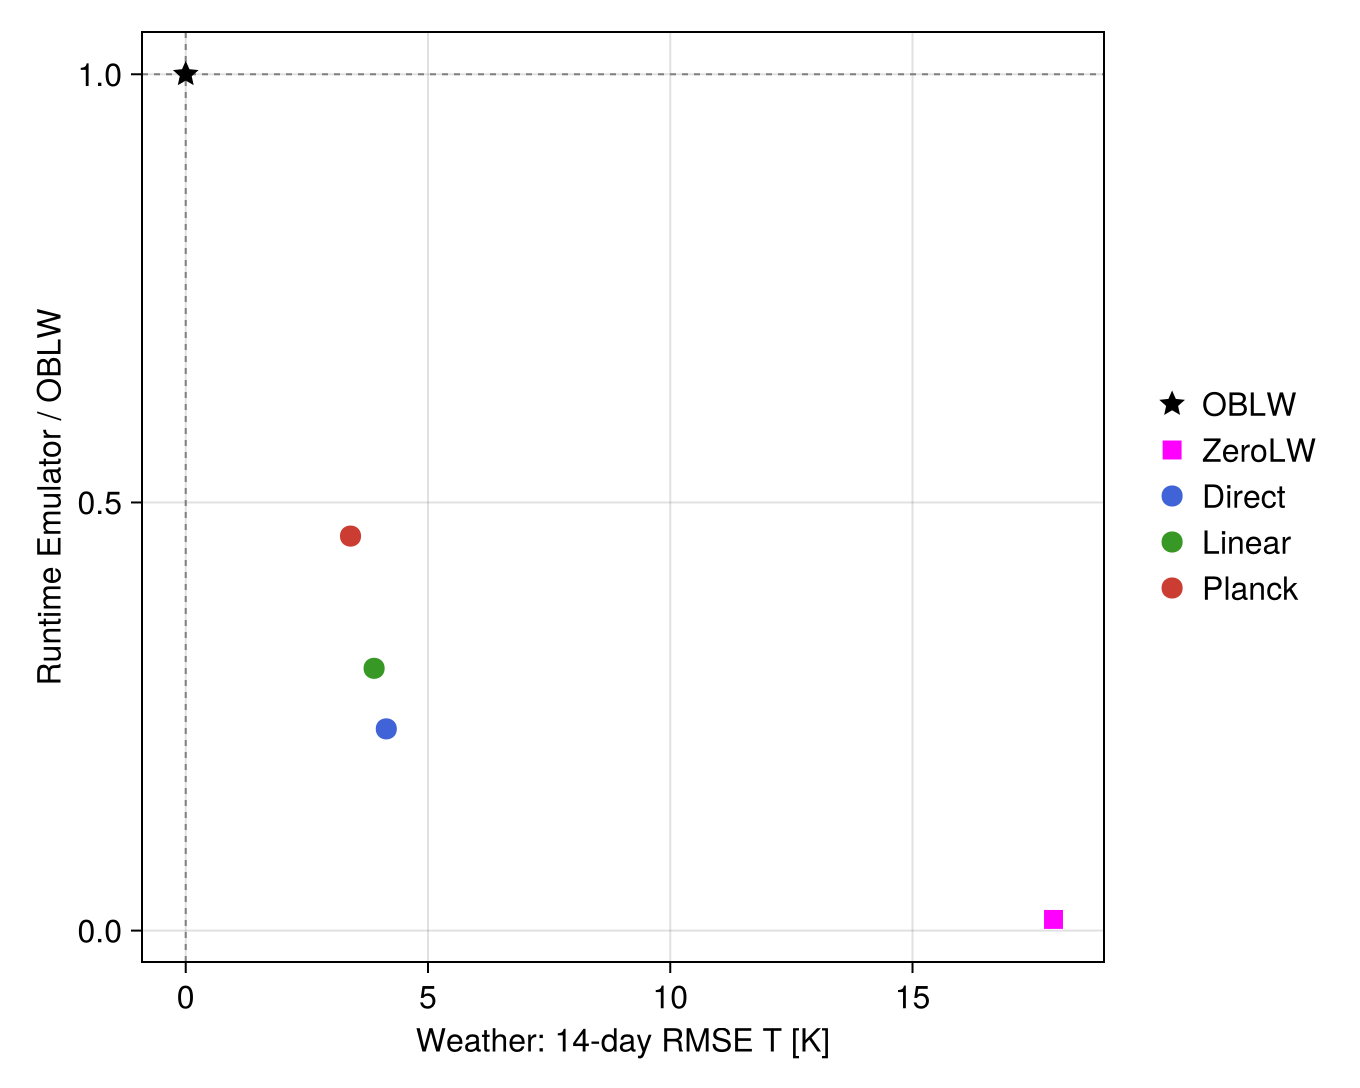

In [193]:
# Plot weather cost plane
plot_weather_cost_plane(wt, tt; looks)

## **3. Weather**

In [194]:
# Load RMSE caps
caps = load_reference("OBLW", "spinup", "rmse_caps.jld2");

### 3.1. ZeroLW Baseline

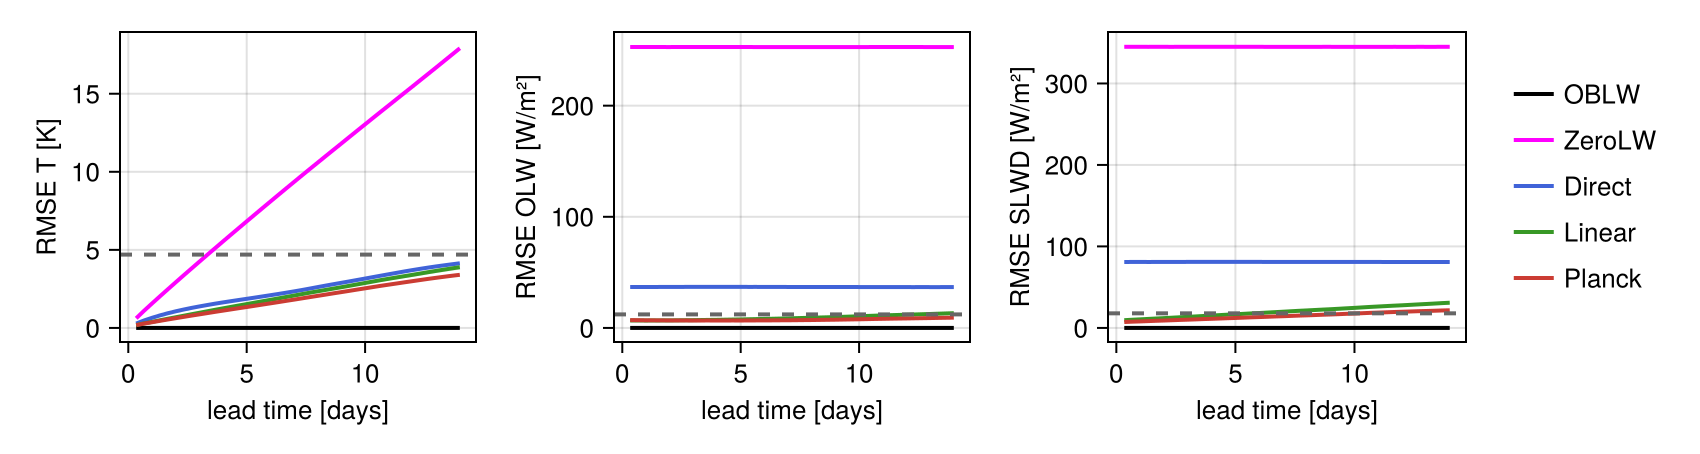

In [195]:
# Plot weather growth RMSE
plot_weather_growth(w, :rmse; caps, looks)

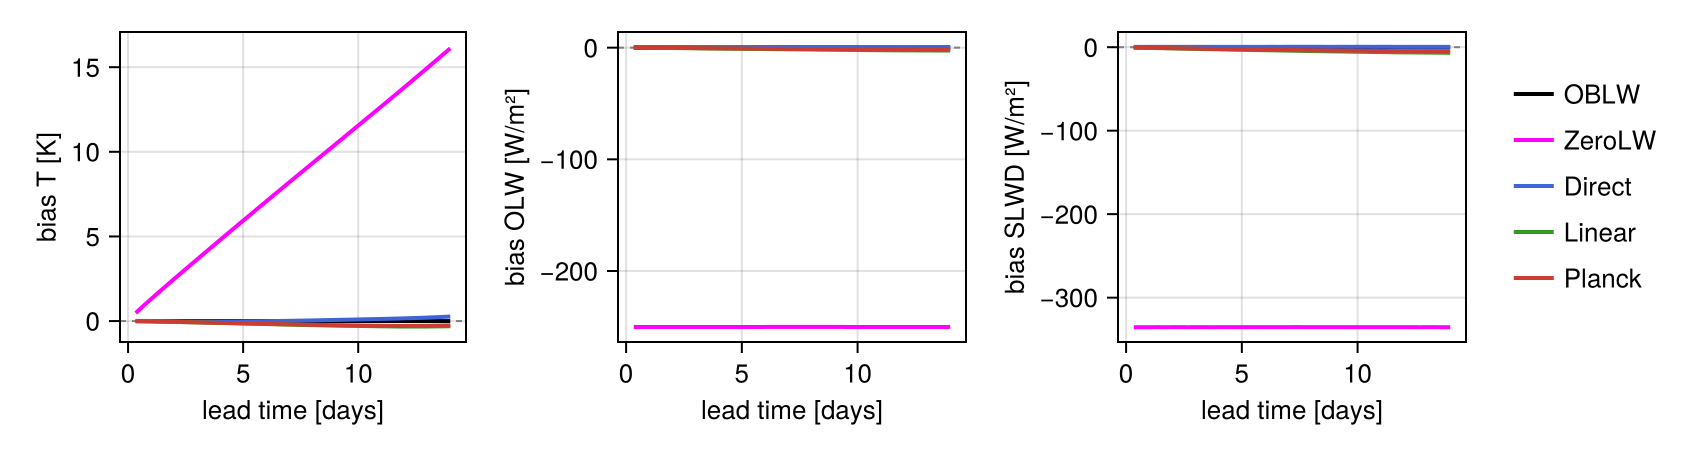

In [196]:
# Plot weather growth bias
plot_weather_growth(w, :bias; caps, looks)

### 3.2. Output Forms

In [197]:
# Collect emulator weather rollouts
w_em = merge(collect_rollouts(EXP, SER, UNITS, leg=:weather));

#### 3.2.1. Weather Growth

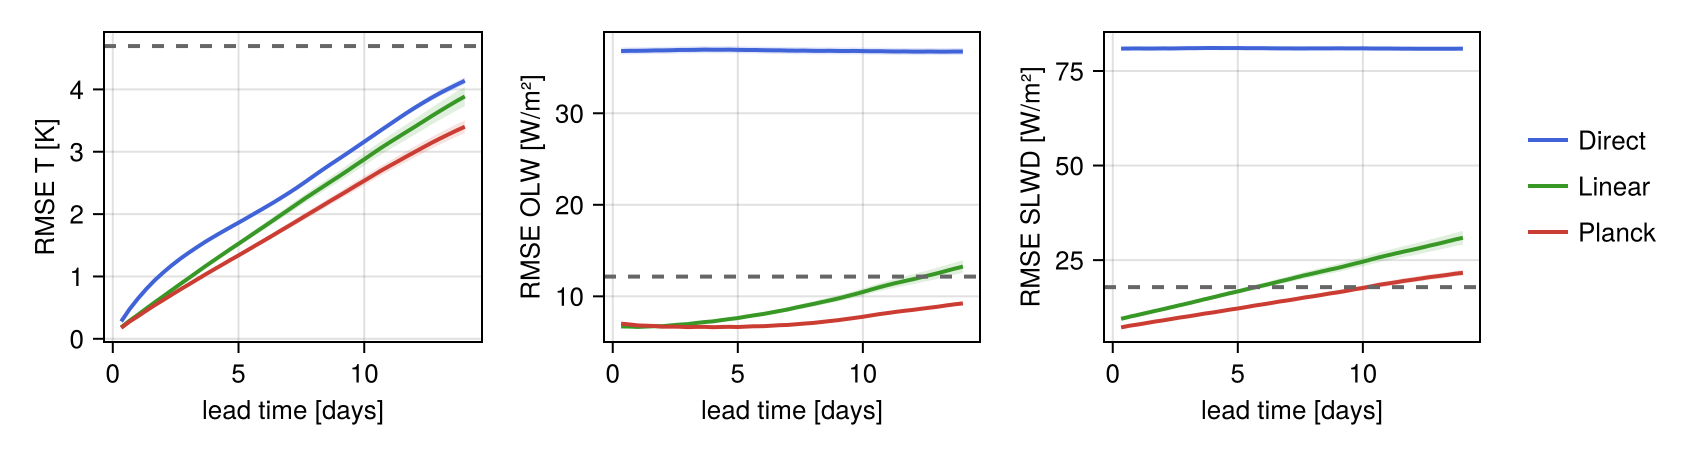

In [198]:
# Plot weather growth RMSE
plot_weather_growth(w_em, :rmse; caps, looks)

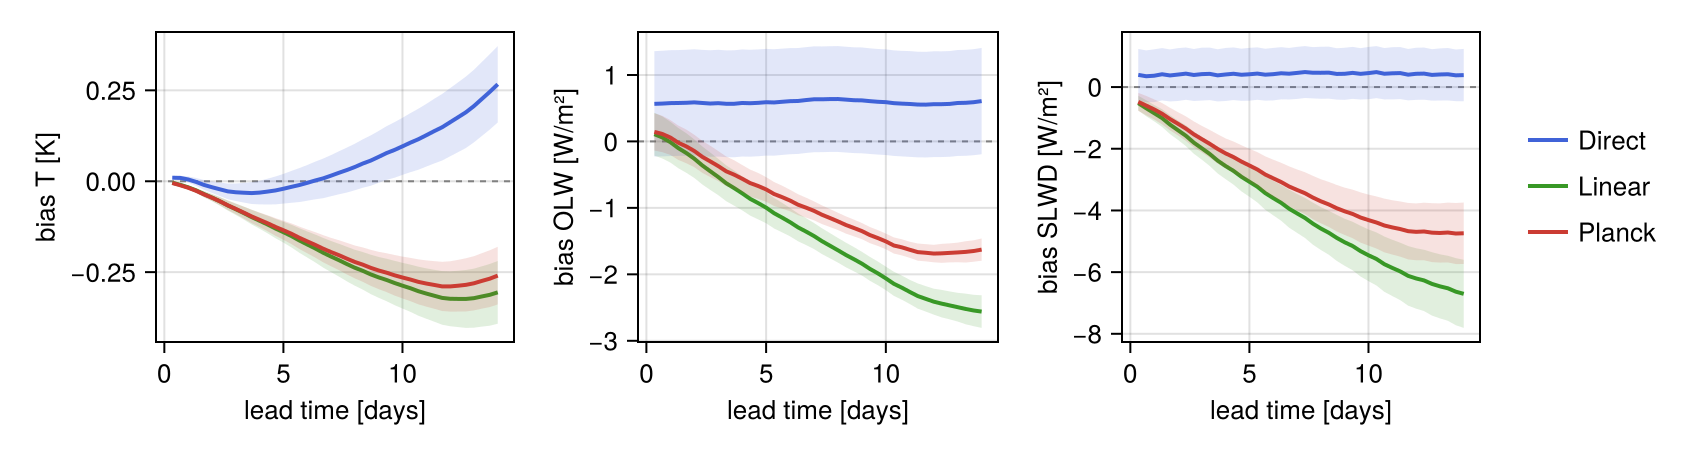

In [199]:
# Plot weather growth bias
plot_weather_growth(w_em, :bias; caps, looks)

#### 3.2.2. Temperature Profile

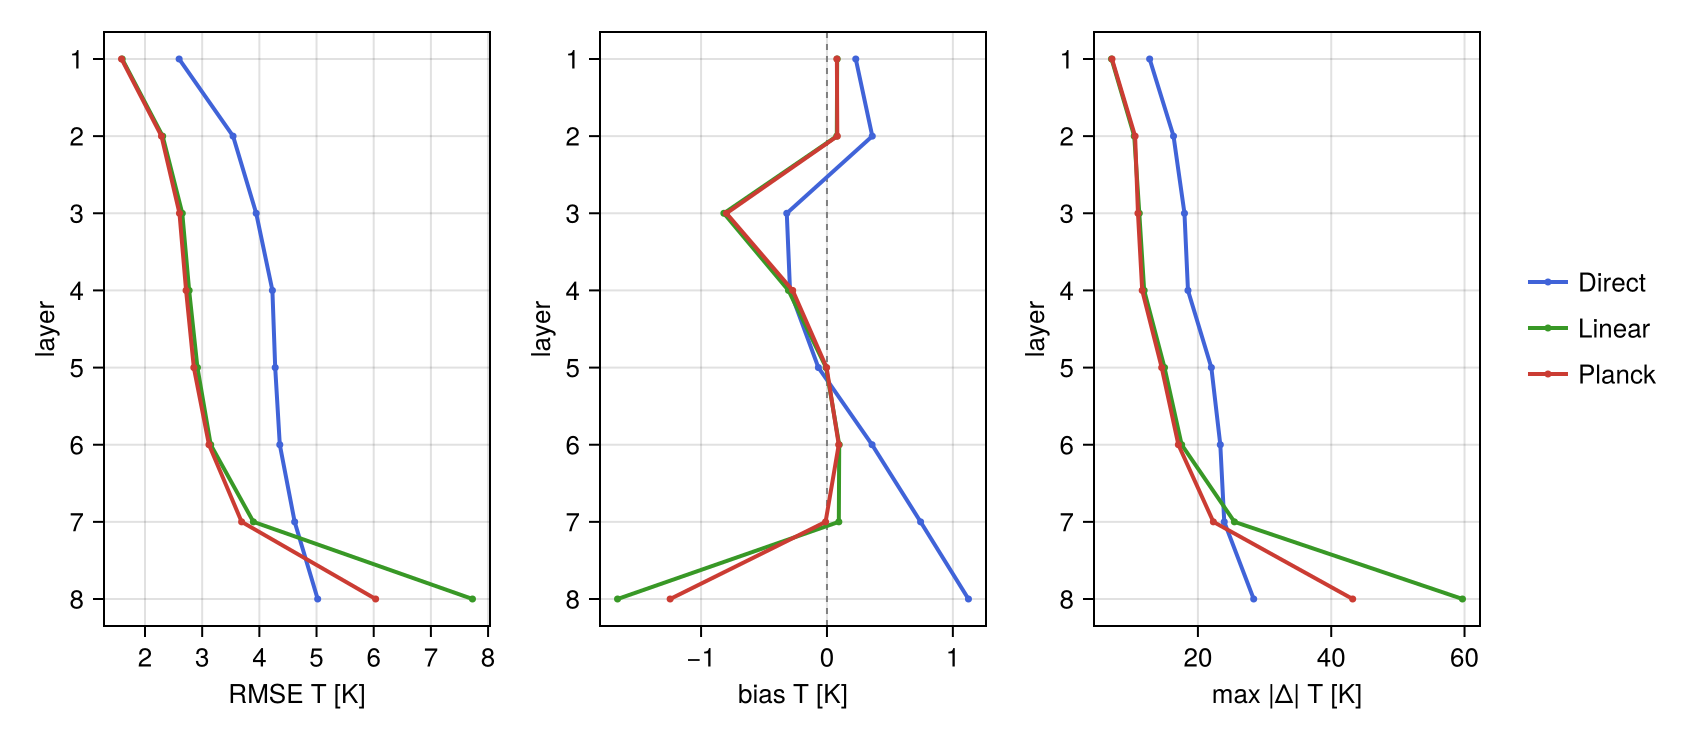

In [200]:
# Temperature profile after 14 days
plot_weather_profile(w_em, :T, 14; looks)

#### 3.2.3. Zonal Sections

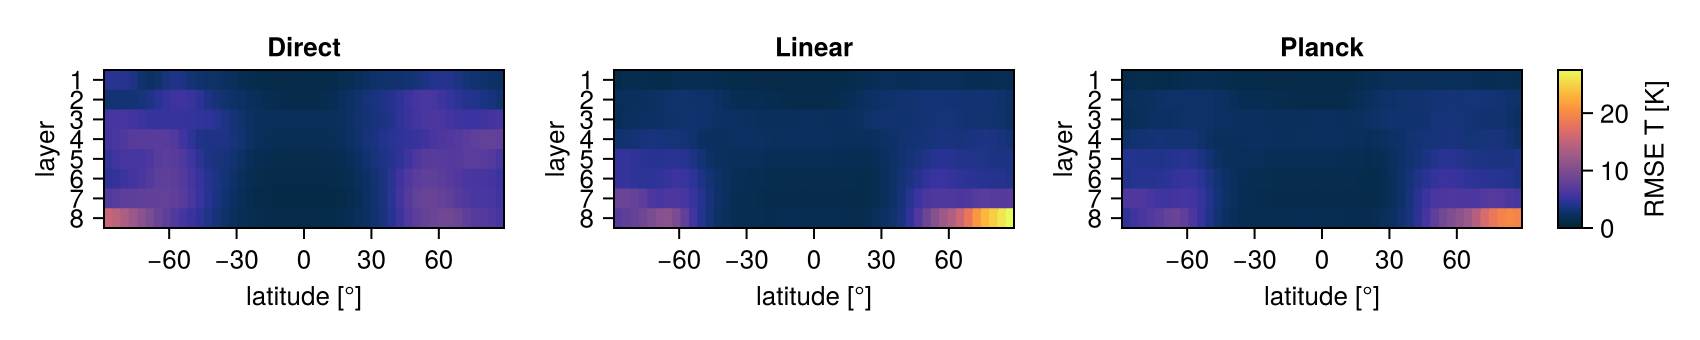

In [201]:
# Zonal temprature rmse section after 14 days
plot_weather_zonal(w_em, :T, 14, :rmse; looks)

#### 3.2.4. LonLat Maps

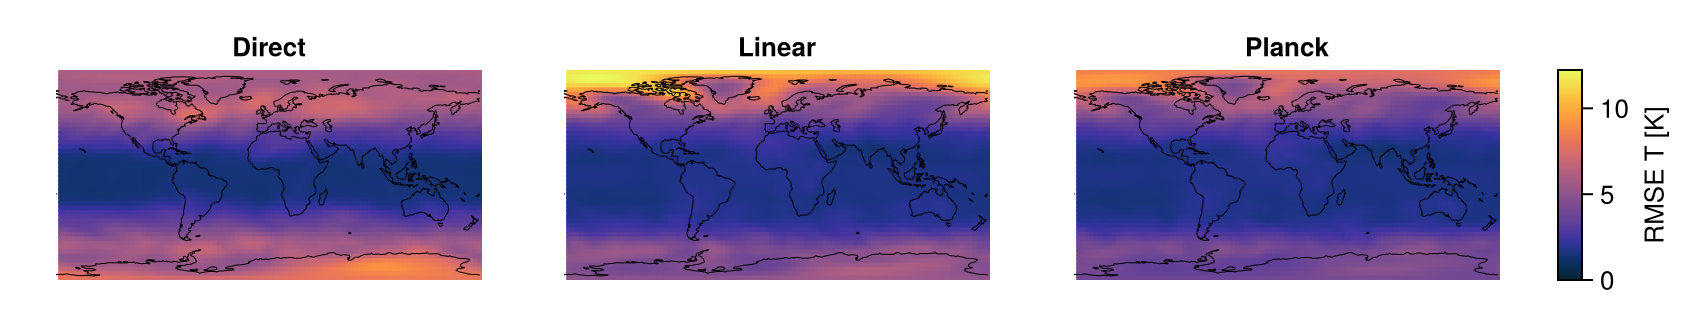

In [202]:
# LonLatMaps of rmse after 14 days
plot_weather_lonlat(w_em, :T, 14, :rmse; looks)

## **4. Climate**

In [203]:
# Load reference and noise climate
clim_ref = load_reference("OBLW", "climate_ref", "climate.jld2");
clim_noise = load_reference("OBLW", "climate_noise", "climate.jld2");

# Merge noise to emulator rollouts
c_pert = merge((;clim_noise), c);

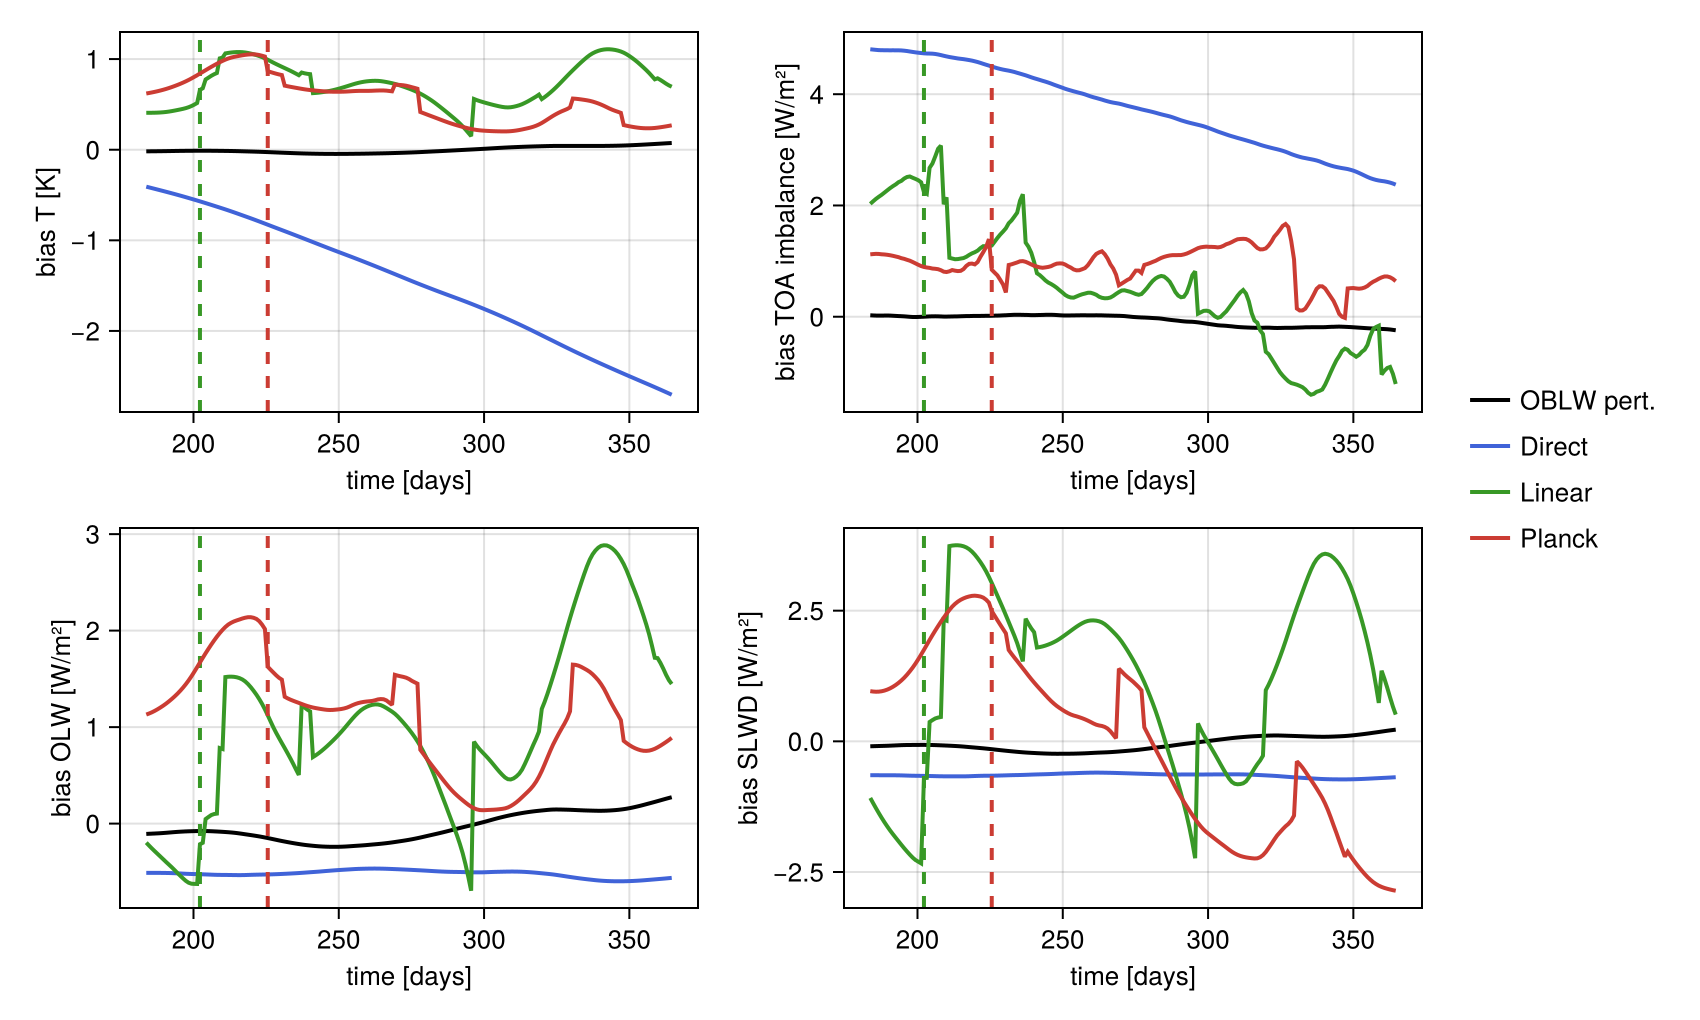

In [204]:
# Plot drift
plot_climate_drift(c_pert, clim_ref; days = (0, 365), looks, style = (;band=false))   